**B.Y.T.E Task 5: Twitter Sentiment Analysis**
1. Data Exploration
2. Data Cleaning Preprocessing
3. Some Visualizations and Key Insights 

**First: Data Exploration**

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [2]:
#Loading the tweet file 
df_tweet = pd.read_csv('Tweets.csv')
df_tweet

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [3]:
#Displaying the first 5 rows in the dataset
df_tweet.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
#Exploring the last 5 rows in the dataset
df_tweet.tail()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [5]:
#Exploring the information of the dataset
df_tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [6]:
#Exploring number of rows and columns in the dataset
df_tweet.shape

(14640, 15)

In [7]:
#Exploring names of columns in the dataset
df_tweet.columns.tolist()

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

In [8]:
#Exploring the index in the dataset
df_tweet.index

RangeIndex(start=0, stop=14640, step=1)

In [10]:
#Exploring the datatype od each column in the dataset
df_tweet_dtype = pd.DataFrame({'Column': df_tweet.columns, 'Data Type': df_tweet.dtypes}).reset_index().drop('index', axis = 1)
df_tweet_dtype

,Column,Data Type
0,tweet_id,int64
1,airline_sentiment,object
2,airline_sentiment_confidence,float64
3,negativereason,object
4,negativereason_confidence,float64
5,airline,object
6,airline_sentiment_gold,object
7,name,object
8,negativereason_gold,object
9,retweet_count,int64


In [12]:
#Exploring the values of the first row in the dataset
df_tweet.iloc[0]

tweet_id                                         570306133677760513
airline_sentiment                                           neutral
airline_sentiment_confidence                                    1.0
negativereason                                                  NaN
negativereason_confidence                                       NaN
airline                                              Virgin America
airline_sentiment_gold                                          NaN
name                                                        cairdin
negativereason_gold                                             NaN
retweet_count                                                     0
text                            @VirginAmerica What @dhepburn said.
tweet_coord                                                     NaN
tweet_created                             2015-02-24 11:35:52 -0800
tweet_location                                                  NaN
user_timezone                            Eastern

In [13]:
#Exploring the statistical information in the dataset
df_tweet.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [14]:
#Exploring set of random texts in the dataset 
df_tweet['text'].sample(10, random_state = 42)

4794     @SouthwestAir you're my early frontrunner for ...
10480    @USAirways how is it that my flt to EWR was Ca...
8067     @JetBlue what is going on with your BDL to DCA...
8880     @JetBlue do they have to depart from Washingto...
8292     @JetBlue I can probably find some of them. Are...
927      @united still waiting to hear back. My wallet ...
3165     @united Yes my flight was rebooked. I'm just l...
7894     @JetBlue Thank you ! What about Paris ? Could ...
2818     @united not 100% sure, however my ticket inclu...
9145     @usairways great crew for flight 504 PHX to YV...
Name: text, dtype: object

**Second Part: Data Cleaning and Preprocessing**

In [15]:
#Exploring the sum of null values in each column
df_tweet.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

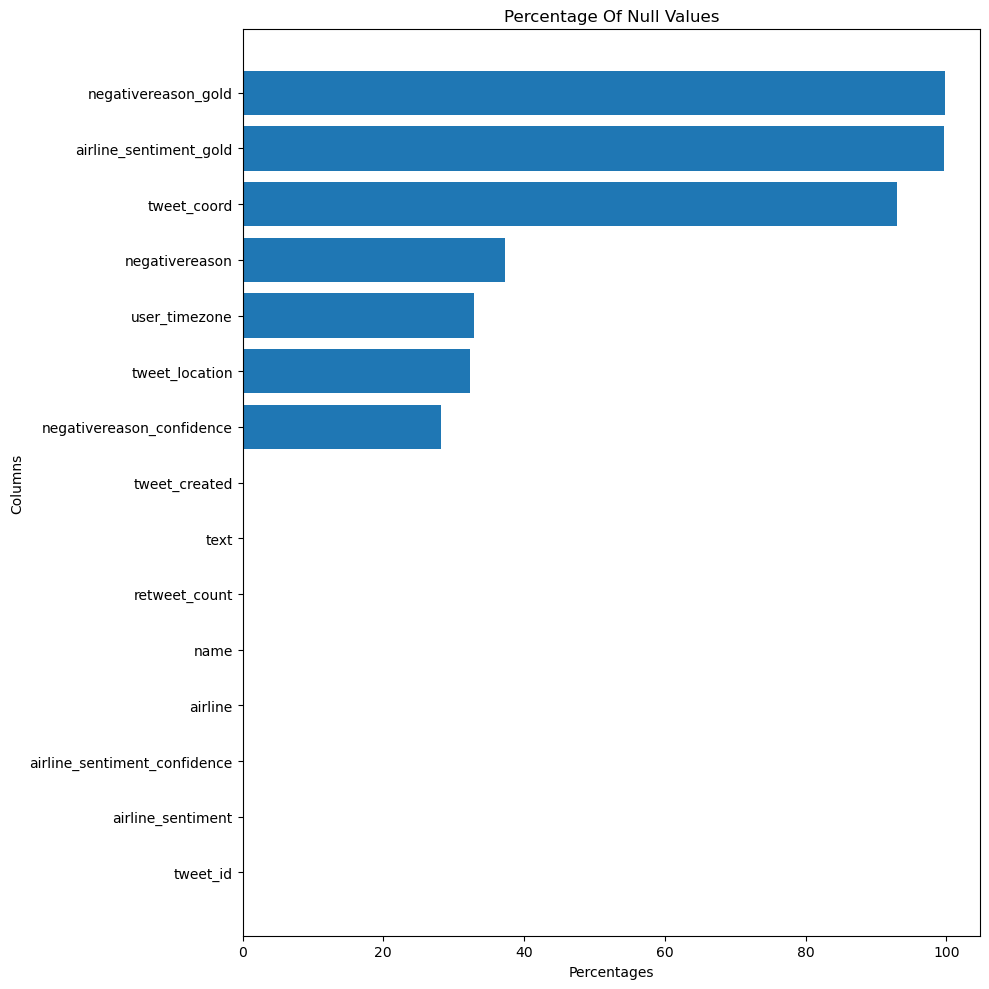

In [17]:
#Visualization of the percentages of null values
null_values_percentages = ((df_tweet.isnull().sum(axis = 0) * 100) / len(df_tweet)).sort_values()
fig, ax = plt.subplots(figsize = (10,10))
ax.barh(null_values_percentages.index, width = null_values_percentages.values)
ax.set_title('Percentage Of Null Values')
ax.set_ylabel('Columns')
ax.set_xlabel('Percentages')
plt.tight_layout()
plt.show()

In [18]:
#Dropping the 3 columns ['negativereason_gold', 'tweet_coord', 'airline_sentiment_gold']
df_tweet = df_tweet.drop(['negativereason_gold', 'tweet_coord', 'airline_sentiment_gold'], axis = 1)
df_tweet.columns.tolist()

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'name',
 'retweet_count',
 'text',
 'tweet_created',
 'tweet_location',
 'user_timezone']

In [19]:
#Exploring the unique values of tweet locations
df_tweet['tweet_location'].unique().tolist()

[nan,
 'Lets Play',
 'San Francisco CA',
 'Los Angeles',
 'San Diego',
 '1/1 loner squad',
 'NYC',
 'San Francisco, CA',
 'palo alto, ca',
 'west covina',
 'this place called NYC',
 'Somewhere celebrating life. ',
 'Boston | Waltham',
 'Boston, MA ',
 '714',
 'San Mateo, CA & Las Vegas, NV',
 'Brooklyn',
 'California, San Francisco',
 'Washington DC',
 'Texas',
 'Worldwide',
 'Central Texas',
 "i'm creating a monster ",
 'Iowa City',
 'Georgia',
 'Turks and caicos',
 'Oakland via Midwest ',
 'New York, NY',
 'Northern Virginia',
 'Los Angeles / Atlanta',
 'new york, new york',
 'brooklyn, Ny',
 'Bali, Republic of Indonesia',
 'UK, USA. ',
 'Gold Coast, Australia',
 'Stockton, CA',
 'Twin Cities, Minn.',
 'USA',
 'next city',
 'SF ↔ NY',
 'New York + Panama',
 'London, England',
 'Floridian from Cincinnati ',
 'Dallas, Texas',
 'Seattle, WA',
 'Lower Pacific Heights, SF, CA',
 'Chicago',
 'Los Cabos,Mexico',
 'Los Angeles, CA',
 'Austin, TX',
 'Sterling Heights, MI',
 'Manhattan Beach, 

In [20]:
#Filling null values of tweet location with not mentioned
df_tweet['tweet_location'] = df_tweet['tweet_location'].fillna('Not Mentioned')

In [23]:
#Exploring the unique values of negativereason
df_tweet['negativereason'].unique().tolist()

[nan,
 'Bad Flight',
 "Can't Tell",
 'Late Flight',
 'Customer Service Issue',
 'Flight Booking Problems',
 'Lost Luggage',
 'Flight Attendant Complaints',
 'Cancelled Flight',
 'Damaged Luggage',
 'longlines']

In [25]:
#Filling the null values of negative reason with not mentioned
df_tweet['negativereason'] = df_tweet['negativereason'].fillna('Not Mentioned')

In [26]:
#Exploring the null values of user_timezone
df_tweet['user_timezone'].unique().tolist()

['Eastern Time (US & Canada)',
 'Pacific Time (US & Canada)',
 'Central Time (US & Canada)',
 'America/New_York',
 'Atlantic Time (Canada)',
 'Quito',
 nan,
 'Mountain Time (US & Canada)',
 'Vienna',
 'Caracas',
 'Kuala Lumpur',
 'Brisbane',
 'Arizona',
 'London',
 'Tehran',
 'Alaska',
 'Sydney',
 'Irkutsk',
 'Santiago',
 'Amsterdam',
 'Tijuana',
 'Abu Dhabi',
 'Central America',
 'Edinburgh',
 'Jerusalem',
 'Hawaii',
 'Paris',
 'Guam',
 'New Delhi',
 'Stockholm',
 'America/Chicago',
 'Berlin',
 'Madrid',
 'Athens',
 'Brussels',
 'Taipei',
 'Rome',
 'Beijing',
 'Mexico City',
 'Bern',
 'Singapore',
 'Indiana (East)',
 'Melbourne',
 'Saskatchewan',
 'Casablanca',
 'Brasilia',
 'Kyiv',
 'Bucharest',
 'Greenland',
 'Prague',
 'New Caledonia',
 'Bogota',
 'Seoul',
 'Sarajevo',
 'Wellington',
 'Bangkok',
 'Warsaw',
 'Copenhagen',
 'Hong Kong',
 'Guadalajara',
 'Mid-Atlantic',
 'Mazatlan',
 'Buenos Aires',
 'America/Los_Angeles',
 'Dublin',
 'Lisbon',
 'Newfoundland',
 'Monterrey',
 'Tokyo',

In [27]:
#Filling the null values of user_timezone with others
df_tweet['user_timezone'] = df_tweet['user_timezone'].fillna('Others')

In [28]:
#Dropping the rows that contains at least one null value
df_tweet = df_tweet.dropna()
df_tweet.isnull().sum()

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
name                            0
retweet_count                   0
text                            0
tweet_created                   0
tweet_location                  0
user_timezone                   0
dtype: int64

In [29]:
#Exploring duplicates
df_tweet.duplicated().sum()

np.int64(21)

In [30]:
#Dropping these duplicated rows
df_tweet = df_tweet.drop_duplicates(keep = 'last')

In [31]:
#Final Check
df_tweet.duplicated().sum()

np.int64(0)

In [32]:
#Converting the tweet_created to datetime 
df_tweet['tweet_created'] = pd.to_datetime(df_tweet['tweet_created'])
df_tweet['tweet_created'].dtype

datetime64[ns, UTC-08:00]

In [33]:
#Dropping unnecessary columns
drop_cols = ['tweet_id', 'name']
df_tweet = df_tweet.drop(drop_cols, axis = 1)
df_tweet.columns

Index(['airline_sentiment', 'airline_sentiment_confidence', 'negativereason',
       'negativereason_confidence', 'airline', 'retweet_count', 'text',
       'tweet_created', 'tweet_location', 'user_timezone'],
      dtype='object')

In [34]:
#Standarize some tweet locations
location_mapping = {
    'nyc': 'new york',
    'new york ny': 'new york',
    'ny': 'new york',
    'san francisco ca': 'san francisco',
    'sf': 'san francisco',
    'los angeles ca': 'los angeles',
    'la': 'los angeles',
    'washington dc': 'washington'
}

# Replace keys with values; leave others alone
df_tweet['tweet_location'] = df_tweet['tweet_location'].replace(location_mapping)

In [36]:
#Downloading the stopwords file
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ibrah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
#Initializing objects for preprocessing texts 
stop_words = stopwords.words('english')
stem = PorterStemmer()
tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)

In [40]:
#The function of processing texts
def process_text(tweet):
    #Removing hyperlinks and URLs
    tweet2 = re.sub(r'RT[\s]+', '', tweet)
    tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)
    tweet2 = re.sub(r'#', '', tweet2)

    #Tokenize the string
    tweet_token = tokenizer.tokenize(tweet2)

    #Removing stop words and punctuations
    tweet_cleans = []
    for word in tweet_token:
        if word not in stop_words and word not in string.punctuation:
            tweet_cleans.append(word)

    #Stemming the words
    tweet_stems = []
    for word in tweet_cleans:
        stem_word = stem.stem(word)
        tweet_stems.append(stem_word)

    return ', '.join(tweet_stems)

In [41]:
#Applying the function to new column 'clean_text'
df_tweet['clean_text'] = df_tweet['text'].apply(process_text)
df_tweet['clean_text'].head(5)

1                plu, ad, commerci, experi, ..., tacki
3    realli, aggress, blast, obnoxi, entertain, gue...
4                              realli, big, bad, thing
5    serious, would, pay, 30, flight, seat, play, r...
6    ye, nearli, everi, time, fli, vx, “, ear, worm...
Name: clean_text, dtype: object

In [45]:
#Making the predicted_sentiment column 
!pip install textblob
from textblob import TextBlob

def get_polarity_class(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    return 'neutral'

df_tweet['predicted_sentiment'] = df_tweet['text'].apply(get_polarity_class)

df_tweet['predicted_sentiment'].head(5)

Defaulting to user installation because normal site-packages is not writeable


1     neutral
3     neutral
4    negative
5    negative
6    positive
Name: predicted_sentiment, dtype: object

**Third Part: Data Viaualization and Key Insights**

C:\Users\ibrah\AppData\Local\Temp\ipykernel_6168\908819707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df_tweet, x = 'airline_sentiment', palette = 'viridis')


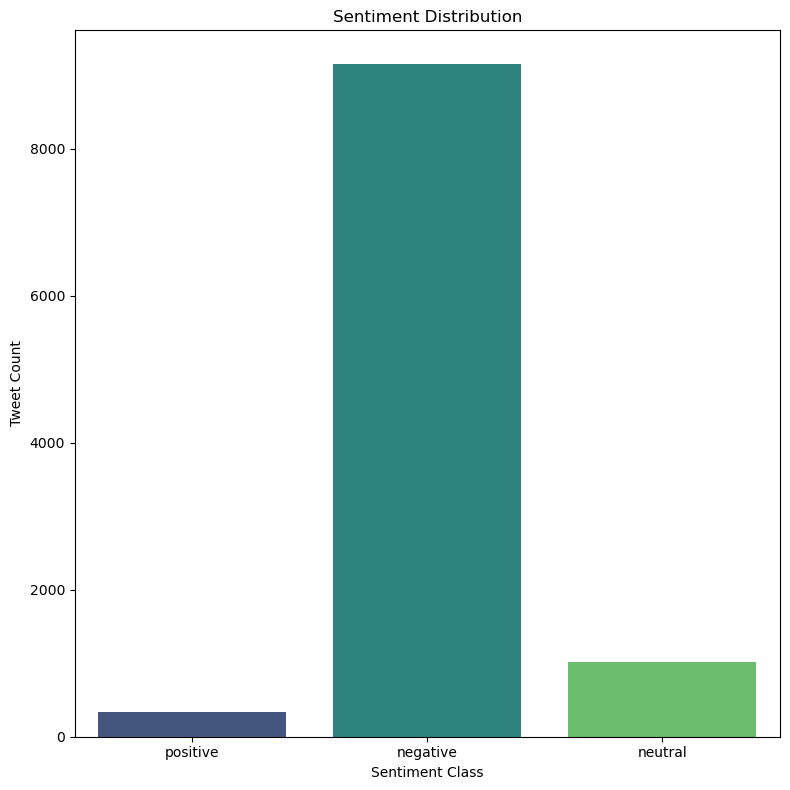

In [47]:
plt.figure(figsize = (8,8))
sns.countplot(data = df_tweet, x = 'airline_sentiment', palette = 'viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Tweet Count')
plt.tight_layout()
plt.show()

**Key Insight To This Visualization:**

This visualization indicates that the most common sentiment in this data is the negative part and indicates that the common appearence of the feedback of the customer towards the airlines is the dissatisfaction

In [48]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


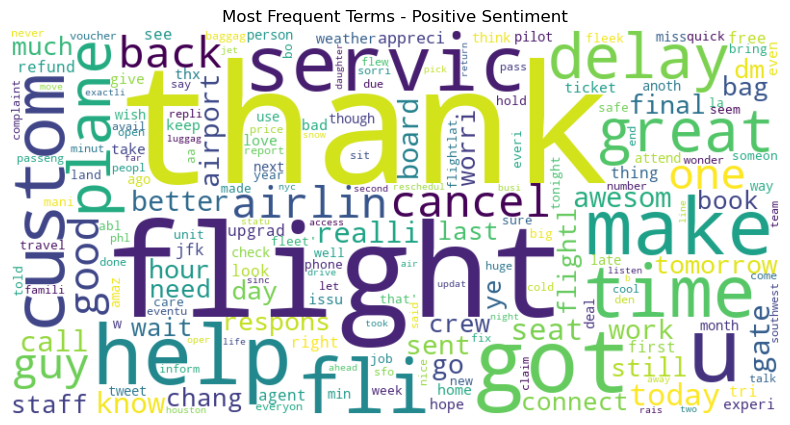

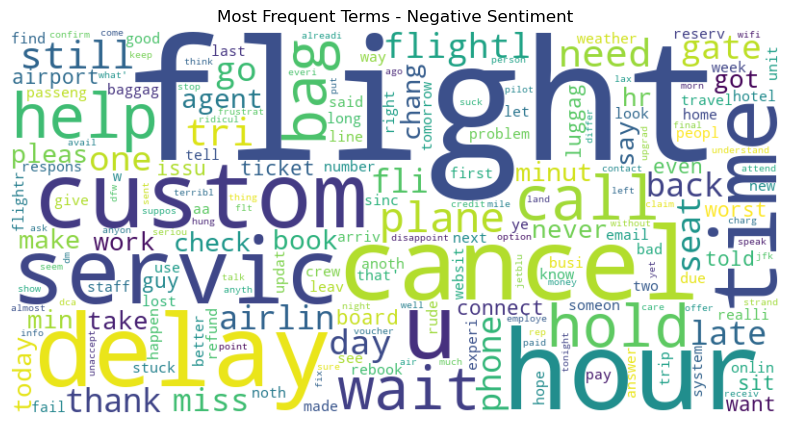

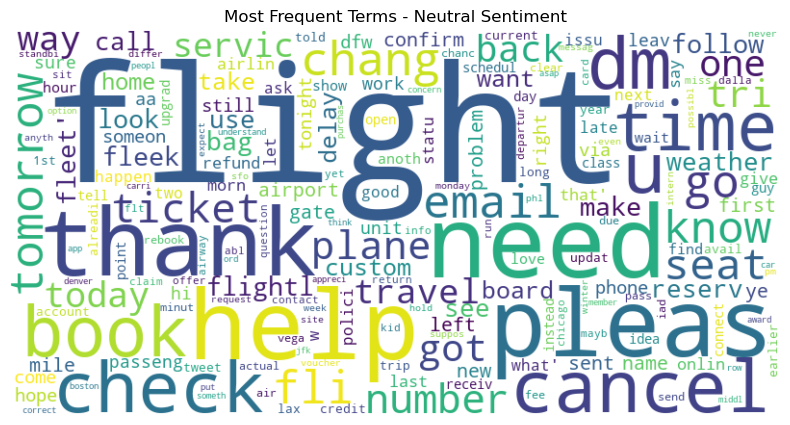

In [50]:
from wordcloud import WordCloud

sentiment_classes = df_tweet['airline_sentiment'].unique().tolist()

for sentiment in sentiment_classes:
    text_corpus = ' '.join(df_tweet[df_tweet['airline_sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width = 800, height = 400, background_color = 'white', collocations = False).generate(text_corpus)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Most Frequent Terms - {sentiment.capitalize()} Sentiment')
    plt.show()

**Key Insight Summary:**

The sentiment analysis reveals a high level of customer dissatisfaction, primarily driven by operational failures like flight delays, cancellations, and lost luggage. Meanwhile, the neutral sentiment word cloud highlights passengers actively seeking customer support, with frequent terms like "help," "DM," and "please."

Actionable Insight: Airlines must prioritize resolving operational bottlenecks, particularly baggage handling and on-time performance. Additionally, empowering social media teams to proactively assist with rebooking and provide real-time updates can significantly convert negative interactions into positive customer experiences.